<a href="https://colab.research.google.com/github/Jeremyy4/DataAnalysis/blob/main/Python2704.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

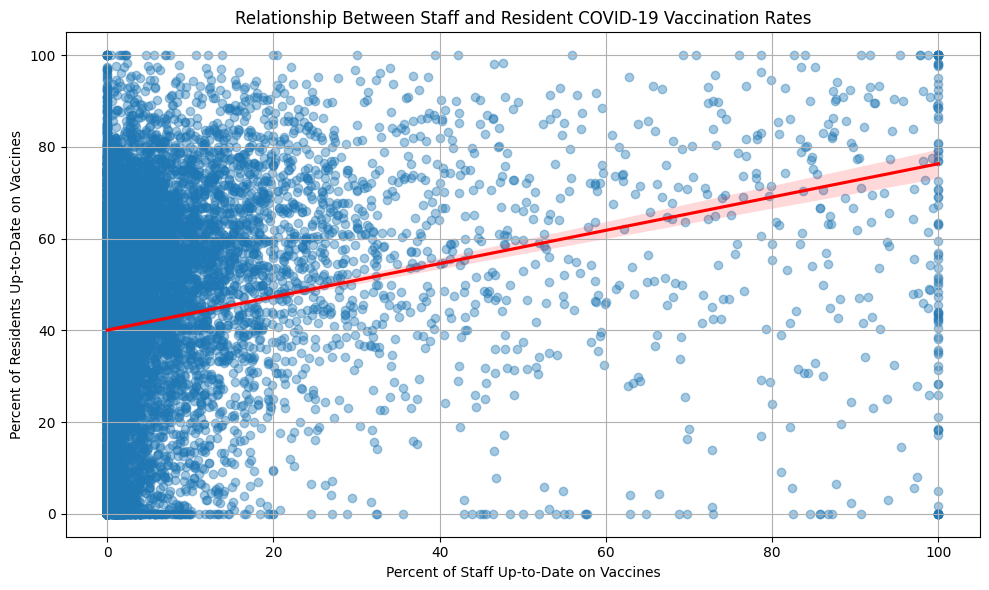

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#read the file
filename = "NH_CovidVaxProvider_20250316.csv"
df = pd.read_csv(filename)

#set column
df['Residents_UpToDate'] = pd.to_numeric(df['Percent of residents who are up-to-date on their vaccines'], errors='coerce')
df['Staff_UpToDate'] = pd.to_numeric(df['Percent of staff who are up-to-date on their vaccines'], errors='coerce')

#drop the miss values(From AI)
df_clean = df.dropna(subset=['Residents_UpToDate', 'Staff_UpToDate'])

# plotting
plt.figure(figsize=(10, 6))
sns.regplot(
    x='Staff_UpToDate',
    y='Residents_UpToDate',
    data=df_clean,
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)
plt.title('Relationship Between Staff and Resident COVID-19 Vaccination Rates')
plt.xlabel('Percent of Staff Up-to-Date on Vaccines')
plt.ylabel('Percent of Residents Up-to-Date on Vaccines')
plt.grid(True)
plt.tight_layout()
plt.show()



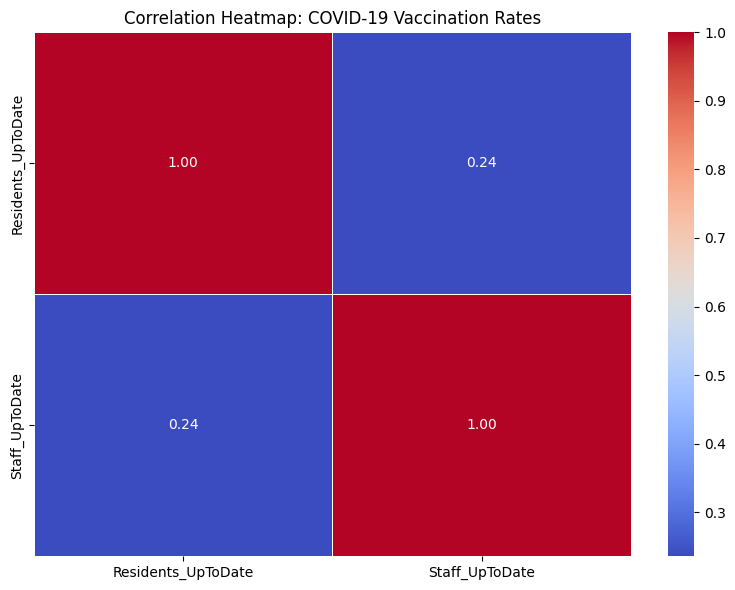

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
filename = "NH_CovidVaxProvider_20250316.csv"
df = pd.read_csv(filename)

# Convert vaccination rate columns to numeric(From AI)
df['Residents_UpToDate'] = pd.to_numeric(df['Percent of residents who are up-to-date on their vaccines'], errors='coerce')
df['Staff_UpToDate'] = pd.to_numeric(df['Percent of staff who are up-to-date on their vaccines'], errors='coerce')

# Filter to numeric columns and drop rows with NaN values
numeric_data = df[['Residents_UpToDate', 'Staff_UpToDate']].dropna()

# compute correlation matrix
corr_matrix = numeric_data.corr()

# plot the heatmap(From AI)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: COVID-19 Vaccination Rates')
plt.tight_layout()
plt.show()


       Residents_UpToDate  Staff_UpToDate  Vaccination_Gap
count        12526.000000    12526.000000     12526.000000
mean            42.821611        7.638408        37.359700
std             24.749238       16.085438        22.925436
min              0.000000        0.000000         0.000000
25%             25.400000        0.000000        18.700000
50%             45.800000        1.800000        39.700000
75%             60.700000        7.500000        54.275000
max            100.000000      100.000000       100.000000


<ipython-input-1-88e4c16b09a0>:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_clean, x='Staff_Vax_Category', y='Residents_UpToDate', ci=None)


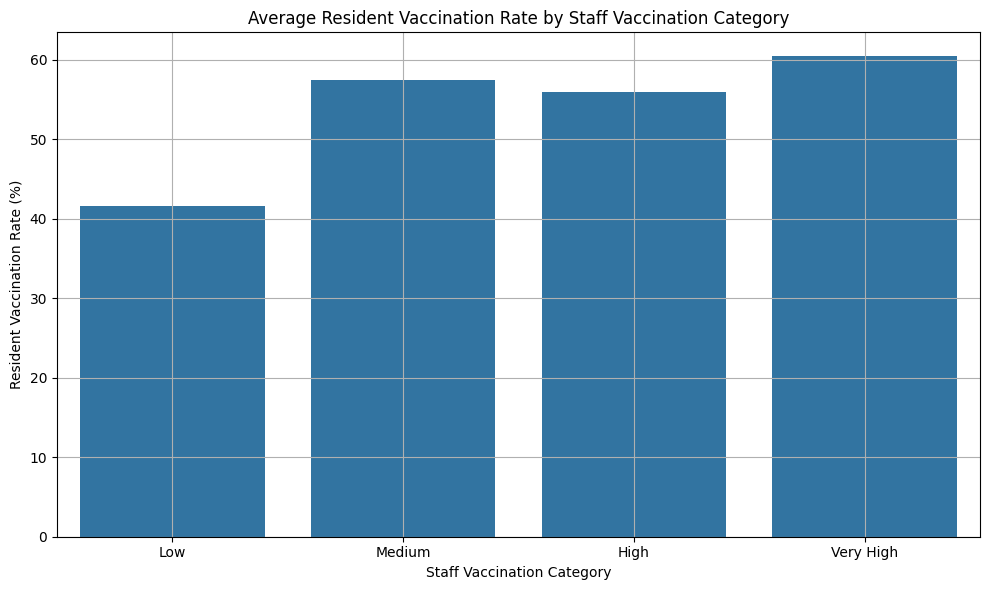

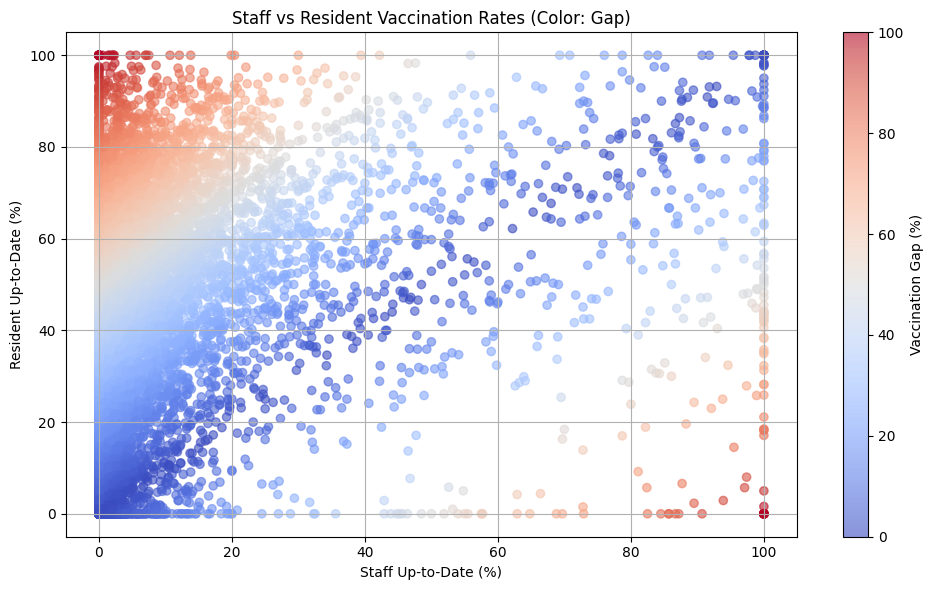

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#read the dataset
filename = "NH_CovidVaxProvider_20250316.csv"
df = pd.read_csv(filename)

#Feature Engineering(Defined by AI)

#Convert vaccination columns to numeric
df['Residents_UpToDate'] = pd.to_numeric(df['Percent of residents who are up-to-date on their vaccines'], errors='coerce')
df['Staff_UpToDate'] = pd.to_numeric(df['Percent of staff who are up-to-date on their vaccines'], errors='coerce')

#Create staff vaccination categories
df['Staff_Vax_Category'] = pd.cut(
    df['Staff_UpToDate'],
    bins=[-1, 25, 50, 75, 100],
    labels=['Low', 'Medium', 'High', 'Very High']
)

#create vaccination gap (absolute difference)
df['Vaccination_Gap'] = abs(df['Residents_UpToDate'] - df['Staff_UpToDate'])
df_clean = df.dropna(subset=['Residents_UpToDate', 'Staff_UpToDate', 'Staff_Vax_Category'])

#Show summary statistics(From AI)
print(df_clean[['Residents_UpToDate', 'Staff_UpToDate', 'Staff_Vax_Category', 'Vaccination_Gap']].describe())

#Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_clean, x='Staff_Vax_Category', y='Residents_UpToDate', ci=None)
plt.title('Average Resident Vaccination Rate by Staff Vaccination Category')
plt.xlabel('Staff Vaccination Category')
plt.ylabel('Resident Vaccination Rate (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

#Scatter Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_clean['Staff_UpToDate'],
    df_clean['Residents_UpToDate'],
    c=df_clean['Vaccination_Gap'],
    cmap='coolwarm',
    alpha=0.6
)
plt.colorbar(scatter, label='Vaccination Gap (%)')
plt.title('Staff vs Resident Vaccination Rates (Color: Gap)')
plt.xlabel('Staff Up-to-Date (%)')
plt.ylabel('Resident Up-to-Date (%)')
plt.grid(True)
plt.tight_layout()
plt.show()


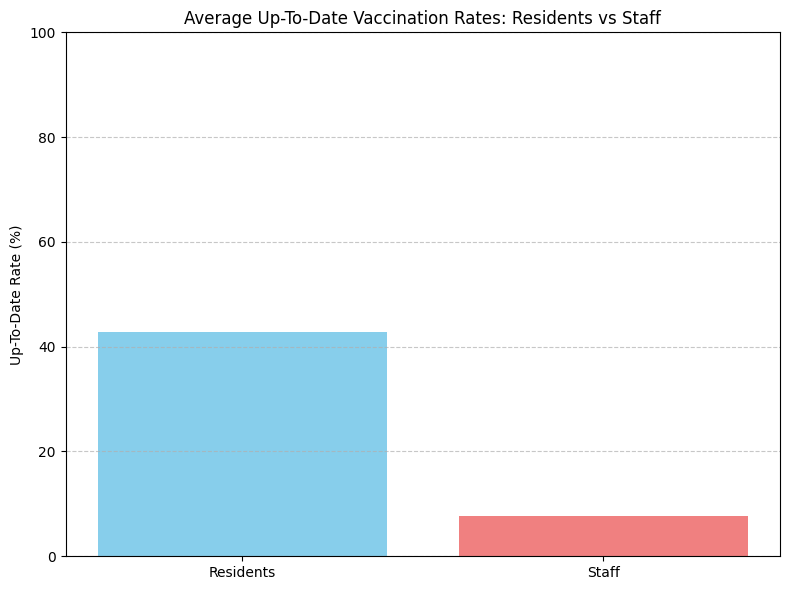

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#read file
filename = "NH_CovidVaxProvider_20250316.csv"
df = pd.read_csv(filename)

#set column
df['Residents_UpToDate'] = pd.to_numeric(df['Percent of residents who are up-to-date on their vaccines'], errors='coerce')
df['Staff_UpToDate'] = pd.to_numeric(df['Percent of staff who are up-to-date on their vaccines'], errors='coerce')

#drop missing values
df_clean = df.dropna(subset=['Residents_UpToDate', 'Staff_UpToDate'])

# calculate average rates, using mean method
average_residents = df_clean['Residents_UpToDate'].mean()
average_staff = df_clean['Staff_UpToDate'].mean()


average_df = pd.DataFrame({
    'Group': ['Residents', 'Staff'],
    'Average Up-To-Date Rate': [average_residents, average_staff]
})

# show graph
plt.figure(figsize=(8, 6))
plt.bar(average_df['Group'], average_df['Average Up-To-Date Rate'], color=['skyblue', 'lightcoral'])
plt.title('Average Up-To-Date Vaccination Rates: Residents vs Staff')
plt.ylabel('Up-To-Date Rate (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import scipy.stats as stats
import numpy as np

filename = "NH_CovidVaxProvider_20250316.csv"
df = pd.read_csv(filename)

df['Residents_UpToDate'] = pd.to_numeric(df['Percent of residents who are up-to-date on their vaccines'], errors='coerce')
df['Staff_UpToDate'] = pd.to_numeric(df['Percent of staff who are up-to-date on their vaccines'], errors='coerce')

df_clean = df.dropna(subset=['Residents_UpToDate', 'Staff_UpToDate'])

#two groups
residents = df_clean['Residents_UpToDate']
staff = df_clean['Staff_UpToDate']

#means, standard deviations, and sizes(using google to search method)
mean_residents = residents.mean()
mean_staff = staff.mean()
std_residents = residents.std()
std_staff = staff.std()
n_residents = len(residents)
n_staff = len(staff)

#z-value
z_value = (mean_residents - mean_staff) / np.sqrt((std_residents**2 / n_residents) + (std_staff**2 / n_staff))

#p-value(Defined by AI)
p_value = 2 * (1 - stats.norm.cdf(abs(z_value)))

#print
print(f"Mean Resident Vaccination Rate: {mean_residents:.2f}%")
print(f"Mean Staff Vaccination Rate: {mean_staff:.2f}%")
print(f"Z-Value: {z_value:.4f}")
print(f"P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: Statistically significant difference between Residents and Staff vaccination rates.")
else:
    print("Result: No statistically significant difference between Residents and Staff vaccination rates.")


Mean Resident Vaccination Rate: 42.82%
Mean Staff Vaccination Rate: 7.64%
Z-Value: 133.4032
P-Value: 0.0000
Result: Statistically significant difference between Residents and Staff vaccination rates.


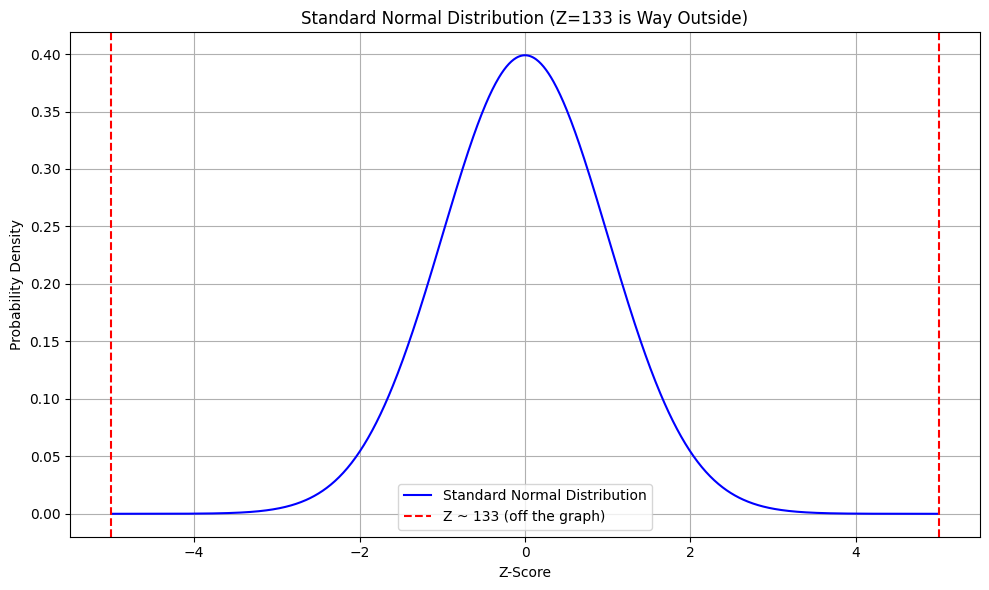

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

x = np.linspace(-5, 5, 1000)
y = stats.norm.pdf(x, 0, 1)

#z-value
z_value_real = 133

#plot the normal distribution(FRom AI)
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Standard Normal Distribution', color='blue')
plt.axvline(x=5, color='red', linestyle='--', label=f'Z ~ {z_value_real} (off the graph)')
plt.axvline(x=-5, color='red', linestyle='--')

#set labels and titles(DEfined by AI)
plt.title('Standard Normal Distribution (Z=133 is Way Outside)')
plt.xlabel('Z-Score')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
